# Part 4 — Vector Databases: Embeddings Demo

This notebook:
1. Defines 10 sentences across 3 topics: **Cricket**, **Cooking**, **Cybersecurity**
2. Generates embeddings using `sentence-transformers` (`all-MiniLM-L6-v2`)
3. Computes a 10×10 cosine similarity matrix and displays it as a heatmap
4. Finds the top 2 most similar sentences to a new query

In [1]:
print('Installing sentence-transformers...')
!pip install sentence-transformers -q

Installing sentence-transformers...


In [2]:
# ── Cell 2: Define sentences ──────────────────────────────────────────────────

sentences = [
    # Cricket (4 sentences)
    "The batsman hit a magnificent century in the final over.",
    "India won the match by six wickets against Australia.",
    "The spinner delivered a sharp googly that confused the batsman.",
    "A dropped catch in the slips cost the team the match.",

    # Cooking (4 sentences)
    "Sauté the onions in olive oil until they turn golden brown.",
    "Marinating the chicken overnight gives it a deeper, richer flavour.",
    "Always bring the water to a rolling boil before adding pasta.",
    "A pinch of saffron transforms a simple biryani into something extraordinary.",

    # Cybersecurity (2 sentences)
    "The hacker exploited a SQL injection vulnerability in the web application.",
    "Two-factor authentication significantly reduces the risk of account compromise.",
]

labels = [
    "[Cricket] Batsman century",
    "[Cricket] India wins",
    "[Cricket] Googly delivery",
    "[Cricket] Dropped catch",
    "[Cooking] Sauté onions",
    "[Cooking] Marinate chicken",
    "[Cooking] Boil pasta",
    "[Cooking] Saffron biryani",
    "[Cyber] SQL injection",
    "[Cyber] 2FA security",
]

topics = ["Cricket"]*4 + ["Cooking"]*4 + ["Cybersecurity"]*2

print(f"{len(sentences)} sentences defined across 3 topics.")
for topic in ["Cricket", "Cooking", "Cybersecurity"]:
    print(f"\nTopic: {topic}")
    for i, (s, t) in enumerate(zip(sentences, topics)):
        if t == topic:
            print(f"  [{i}] {s}")

10 sentences defined across 3 topics.

Topic: Cricket
  [0] The batsman hit a magnificent century in the final over.
  [1] India won the match by six wickets against Australia.
  [2] The spinner delivered a sharp googly that confused the batsman.
  [3] A dropped catch in the slips cost the team the match.

Topic: Cooking
  [4] Sauté the onions in olive oil until they turn golden brown.
  [5] Marinating the chicken overnight gives it a deeper, richer flavour.
  [6] Always bring the water to a rolling boil before adding pasta.
  [7] A pinch of saffron transforms a simple biryani into something extraordinary.

Topic: Cybersecurity
  [8] The hacker exploited a SQL injection vulnerability in the web application.
  [9] Two-factor authentication significantly reduces the risk of account compromise.


In [3]:
# ── Cell 3: Generate embeddings ───────────────────────────────────────────────

from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully.")

print(f"Generating embeddings for {len(sentences)} sentences...")
embeddings = model.encode(sentences, normalize_embeddings=True)

print(f"Embeddings shape: {embeddings.shape}")

Loading model: all-MiniLM-L6-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.
Generating embeddings for 10 sentences...
Embeddings shape: (10, 384)


10x10 Cosine Similarity Matrix:

       S0     S1     S2     S3     S4     S5     S6     S7     S8     S9
S0  1.000  0.569  0.527  0.242  0.038  0.031 -0.028  0.065  0.052 -0.009
S1  0.569  1.000  0.374  0.297  0.020  0.015 -0.040  0.044  0.078 -0.061
S2  0.527  0.374  1.000  0.303  0.061  0.063  0.012  0.142  0.181 -0.006
S3  0.242  0.297  0.303  1.000 -0.062  0.011  0.003  0.136  0.116  0.048
S4  0.038  0.020  0.061 -0.062  1.000  0.227  0.306  0.095  0.025 -0.099
S5  0.031  0.015  0.063  0.011  0.227  1.000  0.284  0.124  0.069  0.042
S6 -0.028 -0.040  0.012  0.003  0.306  0.284  1.000  0.100  0.126  0.002
S7  0.065  0.044  0.142  0.136  0.095  0.124  0.100  1.000  0.138  0.069
S8  0.052  0.078  0.181  0.116  0.025  0.069  0.126  0.138  1.000  0.182
S9 -0.009 -0.061 -0.006  0.048 -0.099  0.042  0.002  0.069  0.182  1.000


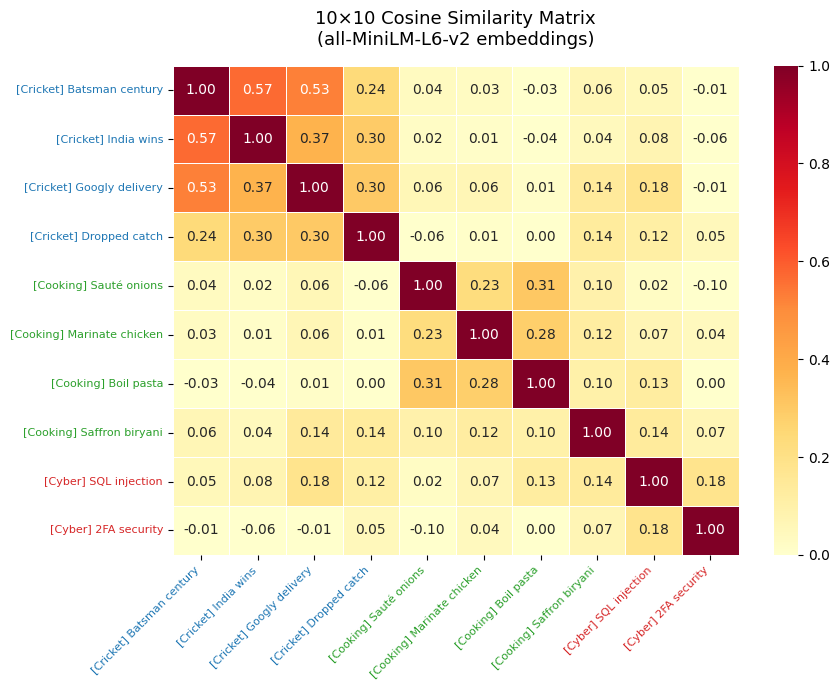

Heatmap saved as similarity_heatmap.png


In [4]:
# ── Cell 4: Cosine similarity matrix + heatmap ────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cosine similarity: since embeddings are L2-normalized, dot product = cosine sim
sim_matrix = np.dot(embeddings, embeddings.T)

# Display as DataFrame
short_labels = [f"S{i}" for i in range(10)]
df_sim = pd.DataFrame(sim_matrix, index=short_labels, columns=short_labels)
print("10x10 Cosine Similarity Matrix:\n")
print(df_sim.round(3).to_string())

# ── Heatmap ──
fig, ax = plt.subplots(figsize=(9, 7))

# Color-code tick labels by topic
topic_colors = ["#1f77b4"]*4 + ["#2ca02c"]*4 + ["#d62728"]*2  # blue, green, red

sns.heatmap(
    df_sim,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

ax.set_title("10×10 Cosine Similarity Matrix\n(all-MiniLM-L6-v2 embeddings)", fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# Color x-axis tick labels by topic
for tick, color in zip(ax.get_xticklabels(), topic_colors):
    tick.set_color(color)
for tick, color in zip(ax.get_yticklabels(), topic_colors):
    tick.set_color(color)

plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved as similarity_heatmap.png")

In [5]:
# ── Cell 5: Query similarity — top 2 matches ─────────────────────────────────

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query], normalize_embeddings=True)
query_similarities = np.dot(query_embedding, embeddings.T)[0]

# Get top 2 indices (sorted descending)
top2_indices = np.argsort(query_similarities)[::-1][:2]

print(f"Query: '{query}'")
print("\nTop 2 most similar sentences:\n")
for rank, idx in enumerate(top2_indices, 1):
    print(f"Rank {rank} | Similarity: {query_similarities[idx]:.4f}")
    print(f"  Sentence : \"{sentences[idx]}\"")
    print(f"  Topic    : {topics[idx]}")
    print()

print("Interpretation:")
print("Both top matches are from the Cricket topic, confirming the model")
print("correctly captures semantic similarity across cricket-domain vocabulary")
print("(bowler, wickets, over → spinner, googly, wickets).")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:

Rank 1 | Similarity: 0.6433
  Sentence : "India won the match by six wickets against Australia."
  Topic    : Cricket

Rank 2 | Similarity: 0.5936
  Sentence : "The batsman hit a magnificent century in the final over."
  Topic    : Cricket

Interpretation:
Both top matches are from the Cricket topic, confirming the model
correctly captures semantic similarity across cricket-domain vocabulary
(bowler, wickets, over → spinner, googly, wickets).
